# **Procesamiento de Lenguaje Natural**

## Maestría en Inteligencia Artificial Aplicada
#### Tecnológico de Monterrey
#### Prof Luis Eduardo Falcón Morales

### **Adtividad en Equipos Semanas 7 y 8 : LDA y LMM audio-a-texto**

* **Nombres y matrículas:**

  *   Elemento de lista
  *   Elemento de lista
  *   Elemento de lista

* **Número de Equipo:**


* ##### **En cada ejercicio pueden importar los paquetes o librerías que requieran.**

* ##### **En cada ejercicio pueden incluir las celdas y líneas de código que deseen.**

# **Ejercicio 1:**

* #### **Liga de los audios de las fábulas de Esopo:** https://www.gutenberg.org/ebooks/21144

* #### **Descargar los 10 archivos de audio solicitados: 1, 4, 5, 6, 14, 22, 24, 25, 26, 27.**



In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 76.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
# Clone whisper.cpp repository
!git clone https://github.com/ggerganov/whisper.cpp.git

Cloning into 'whisper.cpp'...
remote: Enumerating objects: 37691, done.
remote: Counting objects: 100% (563/563), done.
remote: Compressing objects: 100% (245/245), done.
remote: Total 37691 (delta 389), reused 318 (delta 318), pack-reused 37128 (from 4)
Receiving objects: 100% (37691/37691), 40.21 MiB | 12.14 MiB/s, done.
Resolving deltas: 100% (27021/27021), done.


In [5]:
# Build whisper.cpp
!cd whisper.cpp && make

cmake -B build 
CMake Deprecation Warning at CMakeLists.txt:1 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found Git: /usr/bin/git (found version "2.34.1")
-- The ASM compiler identification is GNU
-- Found assemb

In [6]:
# Download the ggml-base.bin model
!cd whisper.cpp && bash ./models/download-ggml-model.sh base

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1077  100  1077    0     0   5743      0 --:--:-- --:--:-- --:--:--  5728
100  141M  100  141M    0     0  28.4M      0  0:00:04  0:00:04 --:--:-- 20.7M
Done! Model 'base' saved in '/content/whisper.cpp/models/ggml-base.bin'
You can now use it like this:

  $ ./build/bin/whisper-cli -m /content/whisper.cpp/models/ggml-base.bin -f samples/jfk.wav



In [7]:
# Incluyan a continuación todas las celdas (de código o texto) que deseen...

import os
from pathlib import Path as p
import librosa as lr
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import subprocess
import json
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import word_tokenize
import spacy
import unicodedata

import gensim
from gensim import corpora
from gensim import models

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

In [8]:
p_audios= p('/content/drive/MyDrive/Colab Notebooks/NLP/Esopo')
print(p_audios)

/content/drive/MyDrive/Colab Notebooks/NLP/Esopo


# **Ejercicio 2a:**

* #### **Comenten el por qué del modelo seleccionado para extracción del texto de los audios.**

* #### **Extraer el contenido de los audios en texto.**

* #### **Sugerencia:** pueden extraerlo en un formato de diccionario, clave:valor $→$ {audio01:fabula01, ...}

In [9]:
path_model=p('/content/whisper.cpp/build/bin/whisper-cli')
path_bin=p('/content/whisper.cpp/models/ggml-base.bin')
dict_trans = {}

# Check if p_audios is defined, if not, create a placeholder for testing
if 'p_audios' not in locals():
    print("WARNING: p_audios variable not found. Using a dummy path for demonstration.")
    p_audios = p('/content/drive/MyDrive/Colab Notebooks/NLP/Esopo') # Placeholder

if not p_audios.exists() or not any(os.listdir(p_audios)): # Check if directory is empty or doesn't exist
    print(f"WARNING: Audio directory {p_audios} is empty or does not exist. Skipping transcription.")
else:
    for mp3 in os.listdir(p_audios):
        f_name = p_audios / p(mp3)
        # Create the command to execute subprocess
        cmd = [str(path_model), "--model", str(path_bin), "--file", str(f_name), "--language", "es"]

        print(f"Transcribing {f_name.stem} using: {' '.join(cmd)}")
        # Perform the transcript of the audio
        result = subprocess.run(cmd, capture_output=True, text=True, encoding='utf-8')

        if result.returncode != 0:
            print(f"Error transcribing {f_name.stem}:\n{result.stderr}")
            transcript = f"Error: {result.stderr}"
        else:
            transcript = result.stdout
            print(f'{f_name.stem}:\n{transcript}')

        # Add the data to the dictionary
        dict_trans[f_name.stem] = transcript

# Write the data to the JSON file
output_json_path = p('/content/drive/MyDrive/Colab Notebooks/NLP/fabulas.json')
with open(output_json_path, "w", encoding="utf8") as f:
    json.dump(dict_trans, f, ensure_ascii=False, indent=2)

print(f"Transcription results saved to {output_json_path}")

Transcribing 01 using: /content/whisper.cpp/build/bin/whisper-cli --model /content/whisper.cpp/models/ggml-base.bin --file /content/drive/MyDrive/Colab Notebooks/NLP/Esopo/01.mp3 --language es
01:

[00:00:00.000 --> 00:00:13.220]   Las fábulas de sopo, grabado para librebox.org/pauLinux, www.pauLinux.info
[00:00:13.220 --> 00:00:24.240]   Fábula número 61, el lobo y el cordero en el templo. Tando se cuenta de que era perseguido
[00:00:24.240 --> 00:00:32.340]   por un lobo, un pequeño cordelito decidió refugiarse en un templo cercano. Lo llamó
[00:00:32.340 --> 00:00:39.160]   lobo y le dijo que si el sacrificador lo encontraba allí adentro, lo emolaría a su
[00:00:39.160 --> 00:00:48.080]   Dios. Mejor así, replicó el cordero, prefiero ser víctima para un Dios a tener que perecer
[00:00:48.080 --> 00:00:56.580]   en tus colmillos. Si sin remedio vamos a ser sacrificados, más nos vale que sea con
[00:00:56.580 --> 00:01:03.840]   el mayor honor. Finn de la fábula. Este es una grabación

**PIPELINE PARA EL PREPROCESAMIENTO DE AUDIO**


1. CARGAR EL ARCHIVO
2. OBTER WAVEFORM Y SAMPLING RATE
3. CALCULAR EL TIEMPO DEL AUDIO:LEN(Y)/SR
4. GRAFICAR LA FORMAD DE ONDA
5. REVISAR DURACIÓN
6. DETECTAR SILENCIAS LARGOS
7. REVISAR AMPLITUD
8. NORMALIZAR O RECORTAR: ESTO SÓLO APLICA PARA AUDIOS MUY GRANDES
9. GUARDAR METADATOS

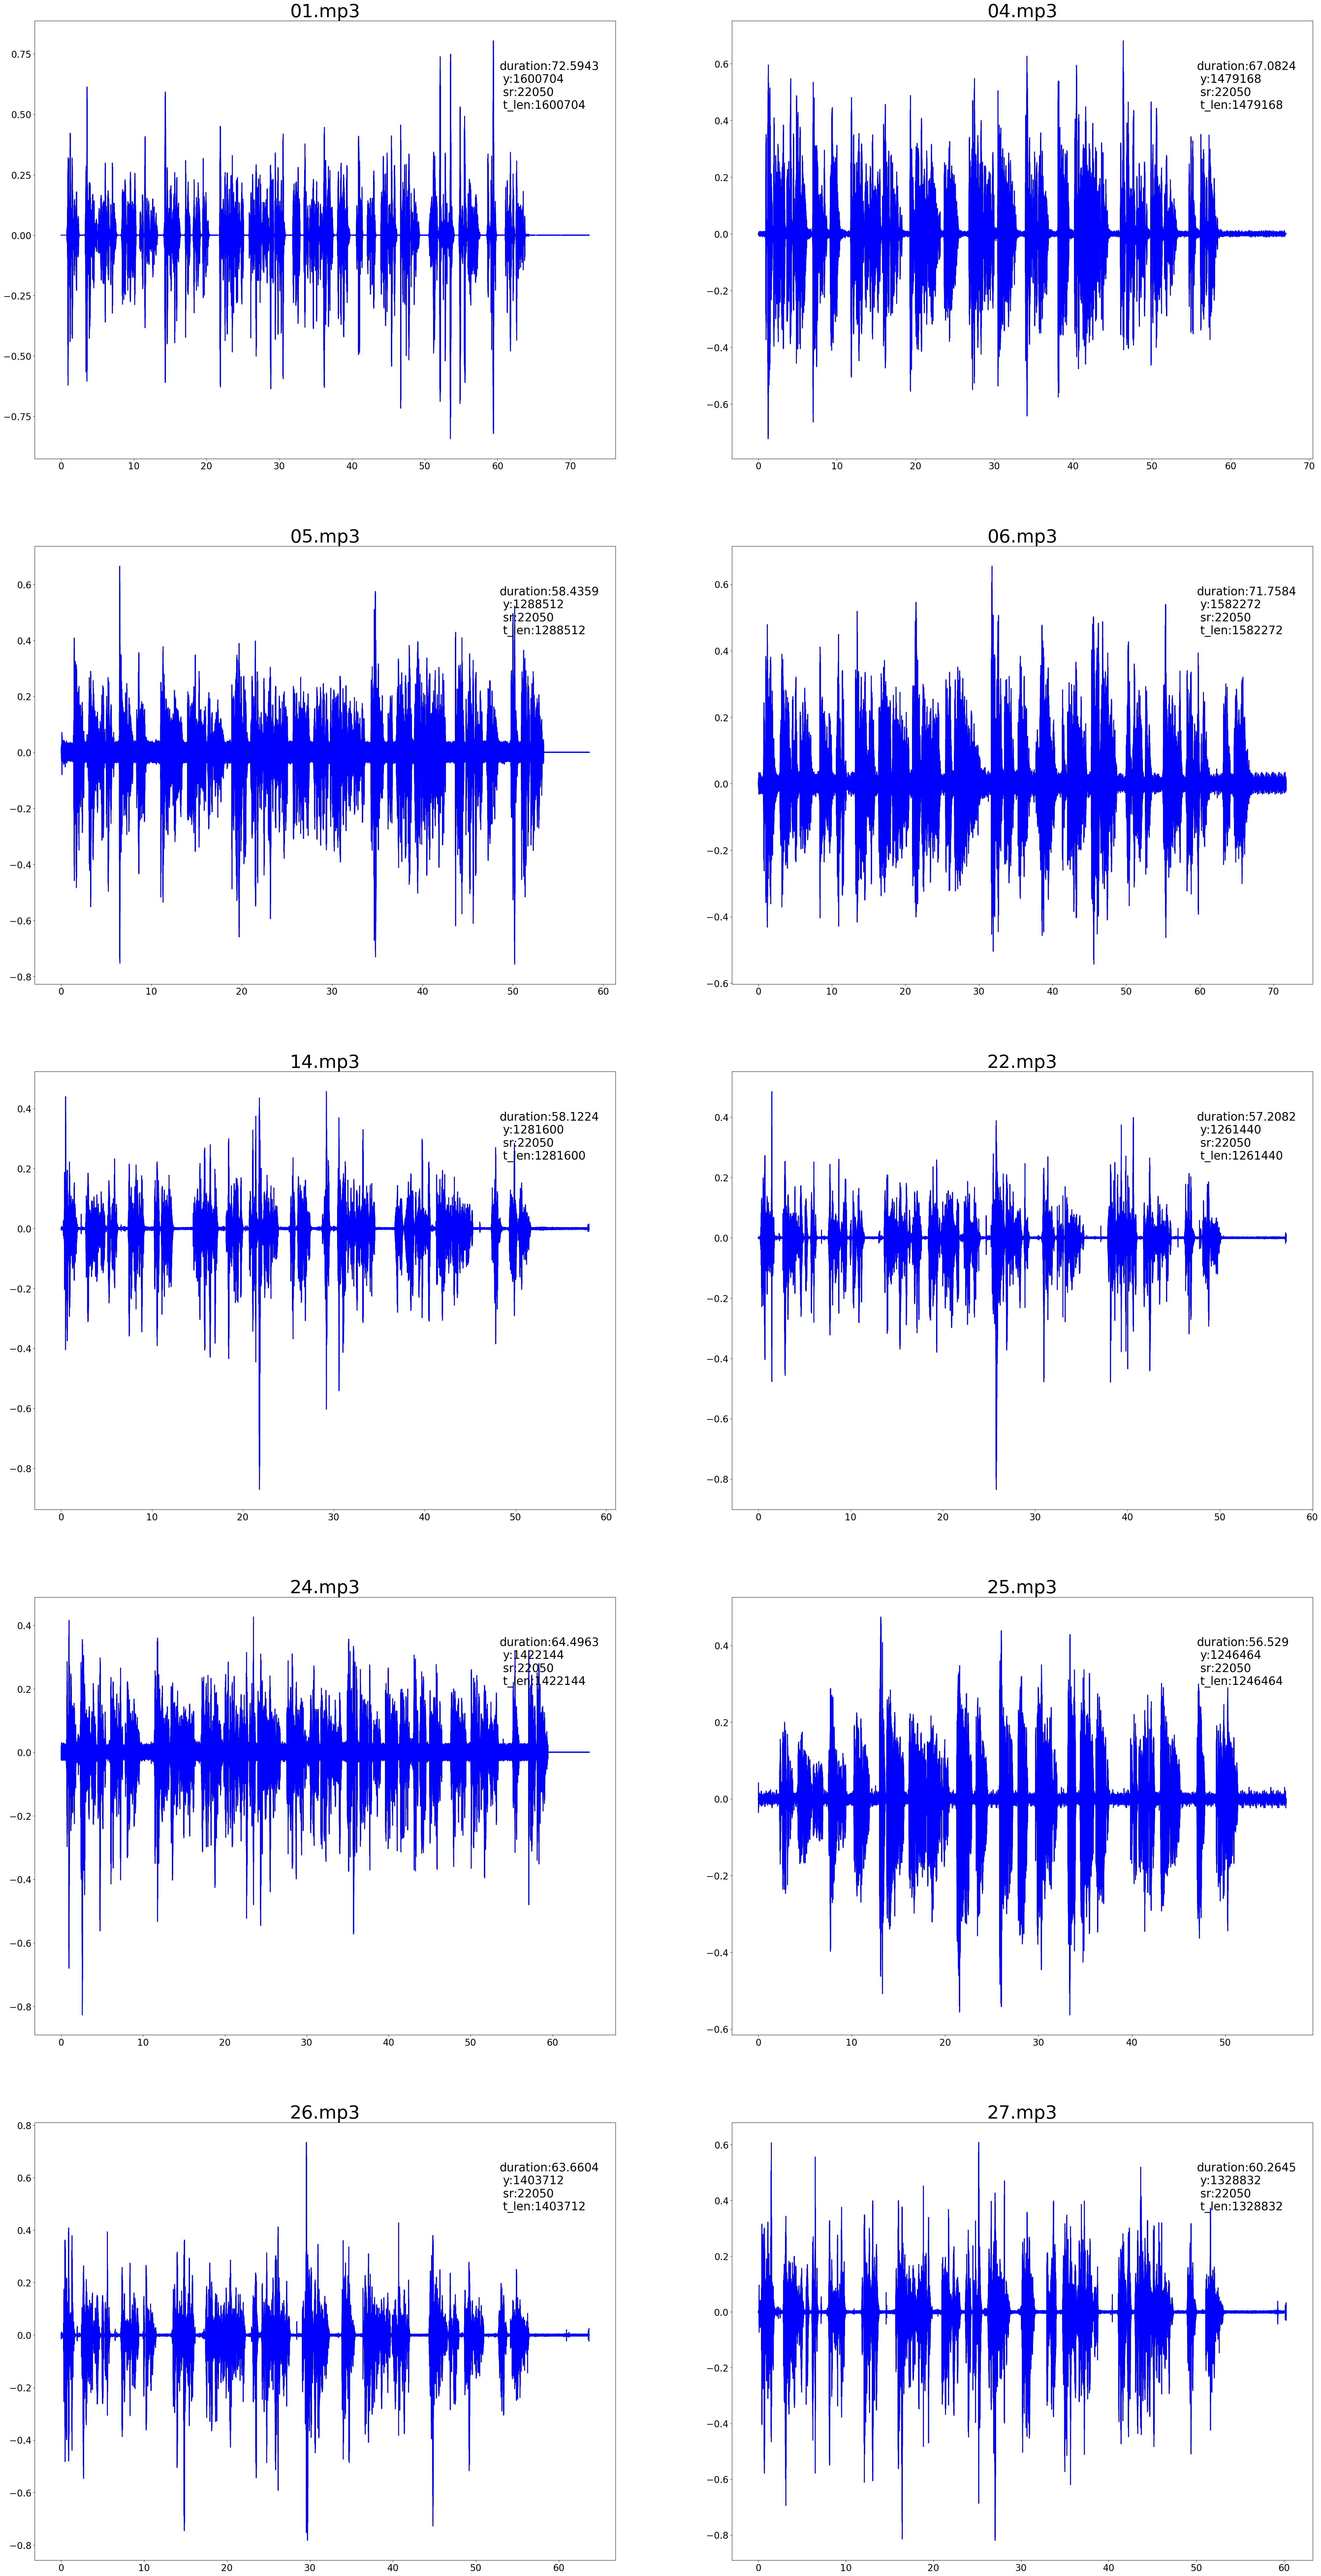

In [10]:
'''
La ventaja de utilizar librosa son las siguientes:
1. Normaliza los valores del audio
2. Arroja un SR, entiendo que es la cantidad de muestras que tiene todo el audio
'''
fig, axes= plt.subplots(ncols=2, nrows=5, figsize=(50,100))
axes=axes.ravel()
i=0
#para cada archivo hacer:
for audio in os.listdir(p_audios):
    #abrir el archivo con librosa
    y,sr=lr.load(p_audios / p(audio))## y-->waveform | sr -->sampling rate
    #obtener duración y número de muestras de y
    len_audio = round(len(y)/sr,4)
    len_y= len(y)
    #obtener la tabla de vectores de tiempo
    t = np.arange(len(y)) / sr
    #obtener forma de onda
    notes=f'duration:{len_audio}\n y:{len_y} \n sr:{sr}\n t_len:{len(t)}'
    axes[i].set_title(f'{audio}', size=40)
    axes[i].text(0.8, 0.8, notes, transform=axes[i].transAxes, size=25)
    axes[i].tick_params(axis='x', labelsize=20)
    axes[i].tick_params(axis='y', labelsize=20)
    line,=axes[i].plot(t,y, color='blue', lw=2)
    i+=1

**Interpretación de las gráficas**

1. Los lectores de los audios 1,4,14,22,26,27 len de manera muy espaciada, respetando mucho los signos de puntación.
2. Se puede apreciar que en los audios 14,24,25,27 presentan de manera recurrente consonantes fuertes (p,k,t) de manera regular.
3. En los audios 5,6,24,25 la velicidad de lectura de los narradores es mucho más rápida, ya que la onda es más apretada y sin tantos valles.
4. Se detecta de manera muy clara la presencia de vocales en todas las ondas, esto lo vemos en la formas, pues en todas se llega a apreciar cierta "redondes" en los espacios cuando hablan las personas.
5. No se detecta que el sonido esté distorsionado (saturación/clipping), pues ningún pico toca el 1 o -1.

**Generación de metadatos**

1. RMS (Root Mean Square) 🎧
- Qué mide: energía promedio del audio.
- Interpretación: volumen percibido.
- Cálculo conceptual:
    - Elevar al cuadrado cada muestra de y
    - Promediar esos valores
    - Sacar raíz cuadrada

2. Energía total 🔋
- Qué mide: cuánta energía contiene el audio completo.
- Cómo: sumatoria de y^2

3. Zero Crossing Rate (ZCR) 🔀
- Qué mide: cuántas veces la señal cambia de signo.
- Interpretación: ruidosidad, consonantes, fricción.
- Cálculo conceptual:
    - Tomar pares consecutivos de muestras
    - Ver si una es positiva y la siguiente negativa (o viceversa)
    - Contar esos cambios

4. Porcentaje de silencio 🤫
- Qué mide: proporción del audio donde no hay voz.
- Cálculo conceptual:
    - Dividir el audio en ventanas pequeñas
    - Calcular RMS o energía por ventana
    - Marcar como “silencio” si está bajo un umbral
    - Contar ventanas silenciosas
    - Dividir entre el total

5. Máxima amplitud 📈
- Qué mide: el valor más alto de la señal.
- Cómo: max(𝑦)
- Interpretación: Si está cerca de 1 → posible clipping.

6. Media y desviación estándar de amplitud 📉
- Media: promedio de todos los valores de y.
- Desviación estándar: variabilidad de la señal.
- Interpretación:
    - Media ≈ 0 → señal centrada
    - Desviación alta → mucha variación en la voz

7. Duración efectiva (sin silencios) 🗣️
- Qué mide: tiempo real donde hay voz.
- Cálculo conceptual:
    - Detectar ventanas que NO son silencio
    - Sumar su duración


8. Relación señal/ruido (SNR) 🔊
- Qué mide: qué tan limpio está el audio.
- Cómo: 𝑆𝑁𝑅 = energía de la señal / energía del ruido
- Cálculo conceptual:
    - Detectar silencios
    - Estimar energía del ruido en esos silencios
    - Comparar con energía total

9. Número de picos fuertes 📌
- Qué mide: cuántos eventos de alta energía hay (consonantes explosivas, golpes, ruidos).
- Cálculo conceptual:
    - Definir un umbral (ej. 0.6 o 0.7)
    - Contar cuántas muestras lo superan
    - (Opcional) agrupar picos cercanos

10. Espectro promedio (opcional) 🎼
- Qué mide: distribución de energía en frecuencia.
- Cálculo conceptual:
    - Aplicar FFT
    - Tomar magnitud
    - Promediar a lo largo del tiempo

In [11]:
y,sr= lr.load(p_audios/p('04.mp3'))
arr_y= np.asanyarray(y)

In [12]:
ws= round(sr*0.02)
#calcular el rms por ventana
rms_win=[np.sqrt(np.mean(np.square(arr_y[i:i+ws]))) for i in range(0,len(arr_y),ws)]
rms_sorted= sorted(rms_win)
l_decil=rms_sorted[:round(len(rms_win)*0.1)]
base_noise=np.average(l_decil) #calculo del promedio de los deciles más bajos para obtener el umbral
win_silent = [val for val in rms_win if val<base_noise]
print(len(win_silent)/len(rms_win))


0.04053651266766021


In [13]:
#Creación de la metadata, del 1-9 solamente
#La metadata se genera por audio, entonces aplicaré un diccionario por audio y todo lo guardo en una lista
#Al final me quedo con una lsita de diccionarios.
#list_metadata=[]
def audio_metrics(path_audio, audio):
    y,sr=lr.load(path_audio)
    arr_y= np.asarray(y)
    tot_duration = round(len(y)/sr,4)
    #TODO: RMS
    rms = np.sqrt(np.mean(np.square(arr_y)))
    #TODO: Energía total
    tot_energy= np.sum(np.square(arr_y))
    #TODO: ZCR
    curr = arr_y[1:]
    prev = arr_y[:-1]
    zcr = np.sum(np.sign(curr)!=np.sign(prev))/len(arr_y)
    #TODO: % silencio
    ws= round(sr*0.02)
    rms_win=[np.sqrt(np.mean(np.square(arr_y[i:i+ws]))) for i in range(0,len(arr_y),ws)]
    rms_sorted= sorted(rms_win)
    l_decil=rms_sorted[:round(len(rms_win)*0.1)]
    base_noise=np.average(l_decil) #calculo del promedio de los deciles más bajos para obtener el umbral
    win_silent = [val for val in rms_win if val<=base_noise]
    per_silent=len(win_silent)/len(rms_win)
    #TODO: Max amplitud
    max_amp = np.max(abs(arr_y))
    #TODO: Media y desv
    prom_y= np.mean(arr_y)
    desv_est = np.std(arr_y)
    #TODO: Duración efectiva
    efec_duration = tot_duration * (1-per_silent)
    #TODO: SNR
    #para calcular necesito signal_energy: promedio del RMS de las ventanas no silenciosas
    win_noise=[val for val in rms_win if val>=base_noise]
    signal_energy= np.mean(win_noise)
    #aplicar la fórmula SNR=signal_energy/ruido_base
    snr=signal_energy/base_noise
    #pasar a decibeles, esto nos da la "nitidex" del audio
    snrdb=20*np.log10(snr)
    #TODO: Número de picos
    k1=0.55#detectar picos sauves de la voz y consonantes
    k2=0.70#detecta golpes y explosiones vocales
    k3=0.85#detecta clipping (saturación)
    #fórumla es k*max_amplitud
    u1=k1*max_amp
    u2=k2*max_amp
    u3=k3*max_amp
    q1= np.sum(np.abs(arr_y)>u1)
    q2= np.sum(np.abs(arr_y)>u2)
    q3=np.sum(np.abs(arr_y)>u3)
    return {
        'rms':rms, 'total_energy':tot_energy, 'zcr':zcr, 'percent_silent':per_silent, 'max_amplitud': max_amp,
        'mean_amplitud':prom_y, 'std_dev_amp': desv_est, 'efective_time':efec_duration, 'snr':snrdb,
        'soft_pikes':q1, 'mid_pikes':q2, 'hard_pikes':q3, 'f_name': audio
        }

**🧠 IDEA CLAVE**

La clasificación final del audio surge de cómo se combinan:
   - SNR
   - % de silencio
   - distribución de picos (suaves, moderados, extremos)
   - RMS / amplitud

Con eso puedes decir si un audio es:
   - limpio
   - normal
   - ruidoso
   - agresivo
   - saturado

**CLASIFICACIÓN DEL AUDIO DE ACUERDO CON LAS MÉTRICAS**
1. SNR (Signal to Noise ratio)

| SNR (dB) | Interpretación |
| --- | --- |
| **> 50 dB** | Audio **muy limpio** |
| **35–50 dB** | Audio **normal / aceptable** |
| **20–35 dB** | Audio **ruidoso** |
| **< 20 dB** | Audio **muy ruidoso / mala calidad** |

2. Porcentaje de silencio

| % silencio | Interpretación |
| --- | --- |
| **< 5%** | Audio continuo |
| **5–20%** | Pausas normales |
| **> 20%** | Audio con mucho silencio |

3. ZCR (Zero Crossing Rate)

| ZCR | Interpretación |
| --- | --- |
| **> 0.15** | Consonantes fuertes, fricción, ruido HF |
| **0.05–0.15** | Voz normal |
| **< 0.05** | Voz suave, ruido grave |

4. RMS (Root Mean Square)

| RMS | Interpretación |
| --- | --- |
| **< 0.05** | Señal suave |
| **0.05–0.10** | Señal normal |
| **> 0.10** | Señal fuerte |

5. Picos
- Suaves:

| Cantidad | Interpretación |
| --- | --- |
| **> 1000** | Muy dinámico / ruidoso |
| **200–1000** | Normal |
| **< 200** | Suave |

- Moderados

| Cantidad | Interpretación |
| --- | --- |
| **> 150** | Agresivo |
| **50–150** | Dinámico |
| **< 50** | Suave |

- Extremos

| Cantidad | Interpretación |
| --- | --- |
| **> 20** | Saturación / clipping |
| **5–20** | Transitorios fuertes |
| **1–5** | Golpes leves |
| **0** | Limpio |


In [14]:
def audio_classifier(l_metrics):

    snr_val = l_metrics.get('snr')
    per_silent_val = l_metrics.get('percent_silent')
    zcr_val = l_metrics.get('zcr')
    rms_val = l_metrics.get('rms')
    sft_pk = l_metrics.get('soft_pikes')
    mod_pk = l_metrics.get('mid_pikes')
    hrd_pk = l_metrics.get('hard_pikes')

    # SNR
    if snr_val >= 50:
        snr_type = 'audio muy limpio'
    elif snr_val >= 35:
        snr_type = 'audio aceptable'
    elif snr_val >= 20:
        snr_type = 'audio ruidoso'
    else:
        snr_type = 'audio con mala calidad'

    # Silencio
    if per_silent_val <= 0.05:
        silent_type = 'audio continuo'
    elif per_silent_val < 0.20:
        silent_type = 'pausas normales'
    else:
        silent_type = 'muchos silencios'

    # ZCR
    if zcr_val >= 0.15:
        zcr_type = 'voz constante fuerte, fricción, ruido HF'
    elif zcr_val > 0.05:
        zcr_type = 'voz normal'
    else:
        zcr_type = 'voz suave | ruido grave'

    # RMS
    if rms_val <= 0.05:
        rms_type = 'señal suave'
    elif rms_val < 0.10:
        rms_type = 'señal normal'
    else:
        rms_type = 'señal fuerte'

    # Picos suaves
    if sft_pk >= 1000:
        sft_type = 'muy ruidoso'
    elif sft_pk > 200:
        sft_type = 'normal'
    else:
        sft_type = 'suaves'

    # Picos moderados
    if mod_pk >= 150:
        mod_type = 'agresivo'
    elif mod_pk > 50:
        mod_type = 'dinámico'
    else:
        mod_type = 'suaves'

    # Picos extremos
    if hrd_pk >= 20:
        hrd_type = 'audio saturado'
    elif hrd_pk >= 5:
        hrd_type = 'transitorios fuertes'
    elif hrd_pk >= 1:
        hrd_type = 'golpes leves'
    else:
        hrd_type = 'limpio'

    # Clasificación general
    if snr_val >= 50 and hrd_pk < 1 and mod_pk < 50:
        audio_type = 'audio limpio'
    elif snr_val >= 35 and hrd_pk < 5 and mod_pk < 150:
        audio_type = 'audio normal'
    elif snr_val >= 25 and sft_pk >= 1000 and mod_pk >= 150:
        audio_type = 'audio ruidoso'
    elif mod_pk >= 150 and hrd_pk >= 5 and hrd_pk < 20:
        audio_type = 'audio agresivo'
    else:
        audio_type = 'audio muy saturado'

    return f"El audio {l_metrics.get('f_name')} se clasifica como {audio_type}.\n\tSNR: {snr_type}\n\tSilencio: {silent_type}\n\tZCR: {zcr_type}\n\tRMS: {rms_type}\n\tPicos suaves: {sft_type}\n\tPicos moderados: {mod_type}\n\tPicos extremos: {hrd_type}"

**🧠 Clasificación Final del Audio**

La clasificación se obtiene combinando: SNR, % de silencio, picos suaves / moderados / extremos, RMS, ZCR

- Reglas generales
    - Audio limpio:
        - SNR > 50 dB
        - picos extremos ≈ 0
        - picos moderados bajos
        - ZCR normal o alto
        - RMS bajo o medio
    - Audio normal
        - SNR 35–50 dB
        - picos extremos bajos
        - picos moderados moderados
        - RMS normal
    - Audio ruidoso
        - SNR 20–35 dB
        - picos suaves muy altos
        - picos moderados altos
        - ZCR alto o muy bajo
    - Audio agresivo
        - picos moderados > 150
        - picos extremos 5–20
        - RMS medio-alto
    - Audio saturado / clipping
        - picos extremos > 20
        - RMS alto
        - max_amplitud cerca de 1.0
        - SNR bajo

In [15]:
l_metrics = [audio_metrics(p_audios / p(mp3), mp3) for mp3 in os.listdir(p_audios)]
for dict in l_metrics:
    print(audio_classifier(dict))

El audio 01.mp3 se clasifica como audio muy saturado.
	SNR: audio muy limpio
	Silencio: audio continuo
	ZCR: voz constante fuerte, fricción, ruido HF
	RMS: señal suave
	Picos suaves: normal
	Picos moderados: agresivo
	Picos extremos: audio saturado
El audio 04.mp3 se clasifica como audio ruidoso.
	SNR: audio ruidoso
	Silencio: audio continuo
	ZCR: voz suave | ruido grave
	RMS: señal normal
	Picos suaves: muy ruidoso
	Picos moderados: agresivo
	Picos extremos: audio saturado
El audio 05.mp3 se clasifica como audio muy saturado.
	SNR: audio ruidoso
	Silencio: pausas normales
	ZCR: voz normal
	RMS: señal normal
	Picos suaves: normal
	Picos moderados: agresivo
	Picos extremos: audio saturado
El audio 06.mp3 se clasifica como audio muy saturado.
	SNR: audio con mala calidad
	Silencio: audio continuo
	ZCR: voz suave | ruido grave
	RMS: señal normal
	Picos suaves: muy ruidoso
	Picos moderados: agresivo
	Picos extremos: audio saturado
El audio 14.mp3 se clasifica como audio muy saturado.
	SNR:

# **Ejercicio 2b:**

* #### **Eliminar el inicio y final comunes de los textos extraídos de cada fábula.**

* #### **Sugerencia:** Pueden guardar esta información en un archivo tipo JSON, para que al estar probando diferentes opciones en los ejercicios siguientes, puedan recuperar rápidamente la información de cada video/fábula.

In [16]:
# Removed the current implementation to prepare for a re-implementation with proper cloning and building of whisper.cpp

In [17]:
output_json_path = p('/content/drive/MyDrive/Colab Notebooks/NLP/fabulas.json')
with open(output_json_path, "rb") as archivo:
    json_dict = json.load(archivo)

print(json_dict)

{'01': '\n[00:00:00.000 --> 00:00:13.220]   Las fábulas de sopo, grabado para librebox.org/pauLinux, www.pauLinux.info\n[00:00:13.220 --> 00:00:24.240]   Fábula número 61, el lobo y el cordero en el templo. Tando se cuenta de que era perseguido\n[00:00:24.240 --> 00:00:32.340]   por un lobo, un pequeño cordelito decidió refugiarse en un templo cercano. Lo llamó\n[00:00:32.340 --> 00:00:39.160]   lobo y le dijo que si el sacrificador lo encontraba allí adentro, lo emolaría a su\n[00:00:39.160 --> 00:00:48.080]   Dios. Mejor así, replicó el cordero, prefiero ser víctima para un Dios a tener que perecer\n[00:00:48.080 --> 00:00:56.580]   en tus colmillos. Si sin remedio vamos a ser sacrificados, más nos vale que sea con\n[00:00:56.580 --> 00:01:03.840]   el mayor honor. Finn de la fábula. Este es una grabación del dominio público.\n', '04': '\n[00:00:00.000 --> 00:00:06.520]   Las fábulas de Soko grabado para LibriBots.org por Roberto Antonio Munoz,\n[00:00:06.520 --> 00:00:11.120]   fábu

In [18]:
def clean_fab(dict):
    list_fab = []
    for k, v in dict.items():
        txt = v[1:-1]
        pat = r"\[\d{2}:\d{2}:\d{2}\.\d{3} --> \d{2}:\d{2}:\d{2}\.\d{3}\]\s*"
        txt = re.sub(pattern=pat, repl='', string=txt)
        txt = re.sub(pattern='\\n', repl=' ', string=txt)
        # Replace multiple spaces with a single space and strip leading/trailing spaces
        txt = re.sub(pattern='\\s{2,}', repl=' ', string=txt).strip()

        # Find start and end markers
        start_match = re.search(pattern='número\\s\\d{2}\\,\\s', string=txt)
        end_match = re.search(pattern='(Fin|Fín|De la fábula)', string=txt)

        start_index = 0
        if start_match:
            start_index = start_match.span()[1]

        end_index = len(txt)
        if end_match:
            end_index = end_match.span()[0]

        # Extract the fable text and strip any remaining spaces
        extracted_txt = txt[start_index:end_index].strip()
        list_fab.append([extracted_txt])
    return list_fab

In [19]:
l_fab = clean_fab(json_dict)
print(l_fab[0:2])

[['el lobo y el cordero en el templo. Tando se cuenta de que era perseguido por un lobo, un pequeño cordelito decidió refugiarse en un templo cercano. Lo llamó lobo y le dijo que si el sacrificador lo encontraba allí adentro, lo emolaría a su Dios. Mejor así, replicó el cordero, prefiero ser víctima para un Dios a tener que perecer en tus colmillos. Si sin remedio vamos a ser sacrificados, más nos vale que sea con el mayor honor.'], ['el logo y la cruzo. A un logo que comía un hueso se le atragandó el hueso en la garganta y corría por todas partes en busta de auxilio. Encontro en su carrera una grulla y le pidió que le salvara de aquella situación y que enseguida le pagaría por ello. Aceptó la grulla e introdujo su cabeza en la boca del logo sacando de la garganta el hueso atravesado. Pidió entonces la cancelación de la paga convenida. Hoy aniga, dijo el logo, "No crees que es suficiente paga con haber sacado tu cabeza sana y salvada en el boca." Nunca hagas favores amalvados, trascant

# **Ejercicio 3:**

* #### **Apliquen el proceso de limpieza que consideren adecuado.**

* #### **Justifiquen los pasos de limpieza utilizados. Tomen en cuenta que el texto extraído de cada fábula es relativamente pequeño.**

* #### **En caso de que decidan no aplicar esta etapa de limpieza, deberán justificarlo.**

In [20]:
def quitar_acentos(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

def doc_cleanse(doc, nlp = spacy.load("es_core_news_sm")):
    # 1. quitar acentos
    doc = quitar_acentos(doc)

    # 2. quitar puntos suspensivos y espacios extra
    doc = re.sub(r'\.+', ' ', doc).strip()
    doc = re.sub(r'\s+', ' ', doc).strip()

    # 3. pasar a minúsculas
    doc = doc.lower()

    # 4. eliminar caracteres especiales (pero conservar ñ)
    doc = re.sub(r'[^a-zñ\s]', '', doc)

    # 5. tokenizar
    doc = word_tokenize(doc)

    # 6. quitar stopwords en español
    es_stpwds = set(stopwords.words('spanish'))
    doc = [w for w in doc if w not in es_stpwds and len(w) > 1]

    # 7. lematizar con spaCy
    doc_spacy = nlp(" ".join(doc))
    tokens = [t.lemma_ for t in doc_spacy]

    return tokens


In [21]:
nltk.download('punkt_tab')
nltk.download('stopwords')
cl_fb = [doc_cleanse(doc=doc[0]) for doc in l_fab]
print(cl_fb[0:3])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[['lobo', 'cordero', 'templo', 'tar', 'contar', 'perseguido', 'lobo', 'pequeno', 'cordelito', 'decidio', 'refugiarse', 'templo', 'cercano', 'llamo', 'lobo', 'decir', 'si', 'sacrificador', 'encontrar', 'alli', 'adentro', 'emolario', 'dio', 'mejor', 'asi', 'replico', 'cordero', 'preferir', 'ser', 'victimo', 'dio', 'tener', 'perecer', 'colmillo', 'si', 'remedio', 'ir', 'ser', 'sacrificar', 'mas', 'valer', 'mayor', 'honor'], ['logo', 'cruzo', 'logo', 'comia', 'hueso', 'atragar', 'hueso', 'garganta', 'corrio', 'todo', 'parte', 'busta', 'auxilio', 'encontro', 'carrera', 'grulla', 'pidio', 'salvar', 'aquel', 'situacion', 'enseguida', 'pagario', 'él', 'aceptar', 'grulla', 'introducir', 'cabeza', 'boca', 'logo', 'sacar', 'garganto', 'hueso', 'atravesado', 'pidio', 'entonces', 'cancelacion', 'pagar', 'convenido', 'hoy', 'aniga', 'decir', 'logo', 'crees', 'suficiente', 'pagar', 'haber', 'sacar', 'cabeza', 'sano', 'salvado', 'boco', 'nunca', 'haga', 'favor', 'amalvado', 'trascant', 'corrupto', 'pu

## **JUSTIFICACIÓN**

Dicho proceso tiene la principal virtud de no perder el contexto de las palabras, ya que al lematizar, la palabra regresa a su raíz y se adpata a las palabras que le ateceden y preceden. Es decir, los adjetivos siguen siendo adjetivos, y lo mismo para los verbos, sustantivos, así como en otras estructuras gramaticales. Igualmente se consideró quitar acentos, espacios, y las stoprwords en español.

El proceso de limpieza se realiza bajo el siguietne pipeline:

# Pipeline de Limpieza y Lematización (`doc_cleanse`)

---

1. Quitar acentos
- Normaliza el texto con `unicodedata.normalize('NFD')`
- Elimina marcas diacríticas (`Mn`)
- Conserva la letra **ñ**

**Resultado:**  
Texto sin acentos, listo para limpieza adicional.

---

2. Normalización básica
- Reemplaza puntos suspensivos `...` por un espacio
- Colapsa espacios múltiples en uno solo
- Aplica `.strip()` para limpiar bordes

**Resultado:**  
Texto limpio y uniforme.

---

3. Convertir a minúsculas
- Convierte todo el texto a minúsculas con `.lower()`

**Resultado:**  
Texto homogéneo para evitar duplicados como “Casa” vs “casa”.

---

4. Eliminar caracteres especiales
- Usa regex para conservar solo:
  - letras a–z  
  - la letra **ñ**  
  - espacios

**Resultado:**  
Texto sin signos, números ni símbolos.

---

5. Tokenización (NLTK)
- Aplica `word_tokenize` para dividir el texto en palabras

**Resultado:**  
Lista de tokens crudos.

---

6. Eliminar stopwords en español
- Carga stopwords con `stopwords.words('spanish')`
- Filtra tokens que:
  - estén en la lista de stopwords  
  - tengan longitud > 1

**Resultado:**  
Tokens significativos sin palabras vacías.

---

7. Lematización con spaCy
- Une tokens en un string: `" ".join(doc)`
- Procesa con `nlp(...)`
- Extrae lemmas con `t.lemma_`

**Resultado:**  
Lista final de lemmas en español, lista para TF‑IDF, LDA o embeddings.

---

8. Retorno
La función devuelve:

```python
['niño', 'estar', 'correr', 'rápido', 'árbol']

# **Ejercicio 4:**

# Pipeline de Modelado de Tópicos con LDA

Este pipeline describe el flujo completo para aplicar **LDA (Latent Dirichlet Allocation)**
a un conjunto de fábulas ya limpias y lematizadas mediante la función `doc_cleanse`.

---

## 1. Preparación de los documentos ---> DONE
- Cada fábula se procesa con `doc_cleanse`.
- El resultado es una lista de tokens lematizados.
- Cada fábula se convierte en un documento representado como una lista de palabras.

**Resultado:**  
Una lista de documentos, donde cada documento es una lista de lemmas.

---

## 2. Construcción del diccionario
- Se crea un diccionario que asigna un ID único a cada palabra del corpus.
- Este diccionario representa el vocabulario total de todas las fábulas.

**Resultado:**  
Un mapeo palabra → ID que LDA puede usar.

---

## 3. Representación Bag‑of‑Words (BoW)
- Cada fábula se convierte en una lista de pares:
  - `(id_palabra, frecuencia)`
- Esta representación ignora el orden de las palabras y solo conserva cuántas veces aparece cada una.

**Resultado:**  
Una matriz BoW lista para alimentar a LDA.

---

## 4. Entrenamiento del modelo LDA
- Se entrena un modelo LDA indicando:
  - `num_topics = 1` (porque cada fábula tiene un solo tópico)
  - Número de palabras clave por tópico (por ejemplo, 20)
- LDA analiza patrones de co‑ocurrencia entre palabras.

**Resultado:**  
Un modelo que identifica el “tema oculto” de cada fábula.

---

## 5. Extracción de palabras clave
- Para cada fábula:
  - Se obtiene su único tópico dominante.
  - Se extraen las palabras más representativas del tópico (20 por defecto).
- Estas palabras son las “palabras clave” que describen el tema de la fábula.

**Resultado:**  
Una lista de 20 palabras clave por fábula.

---

## 6. Despliegue de resultados
- Se muestra para cada fábula:
  - Su número o título
  - Las palabras clave generadas por LDA

**Resultado final:**  
Un resumen temático de cada fábula basado en estadística de co‑ocurrencia.


In [22]:
def topics_LDA(l_fab):
    #2 construcción del diccionario
    fbl_dict = corpora.Dictionary([l_fab])
    #3. Construcción del Bag of words
    BoW=[fbl_dict.doc2bow(l_fab)]
    #4.1 Construcción del modelo LDA
    mlda = models.LdaModel(corpus=BoW, id2word= fbl_dict, num_topics=1)
    #4.2 Top 20 palabras
    topics= mlda.print_topic(topicno=0, topn=20)
    #5. Top 20 palabras --> limpieza
    lf_top20w= [re.sub(pattern='[^A-Za-z]', repl='', string=t) for t in topics.split('+')]
    return lf_top20w

In [23]:
#6. mostrar resultados
audios= os.listdir(p_audios)
dict_top20={}
for fab, mp3 in zip(cl_fb, audios):
    dict_top20[mp3.split(sep='.')[0]]=topics_LDA(fab)

print(dict_top20)

{'01': ['lobo', 'dio', 'si', 'cordero', 'templo', 'ser', 'honor', 'victimo', 'alli', 'tener', 'replico', 'decir', 'pequeno', 'preferir', 'tar', 'perseguido', 'contar', 'valer', 'cercano', 'ir'], '04': ['logo', 'pagar', 'hueso', 'pidio', 'sacar', 'sano', 'grulla', 'cabeza', 'parte', 'trascant', 'situacion', 'tendrias', 'mucho', 'auxilio', 'encontro', 'corrupto', 'hoy', 'pagario', 'amalvado', 'busta'], '05': ['lobo', 'caballo', 'cebado', 'habia', 'sino', 'aunque', 'deber', 'cantidad', 'preferido', 'amigo', 'ir', 'bueno', 'comida', 'complacer', 'almasticarl', 'dejar', 'mas', 'estomago', 'vez', 'reponer'], '06': ['lobo', 'ley', 'asno', 'capturase', 'decir', 'hambre', 'magnifico', 'elegido', 'secretado', 'si', 'alguno', 'epoca', 'congener', 'casa', 'igual', 'tener', 'llegar', 'pusierir', 'primero', 'idea'], '14': ['lobo', 'cabrito', 'sino', 'enfrentamiento', 'ampliamente', 'infeliz', 'arrogante', 'insultarl', 'sitio', 'valor', 'encerrado', 'comenzo', 'serenamente', 'lugar', 'replico', 'corr

## **GENSIM**

🧠 El diccionario permite:
- Definir el vocabulario total del corpus
- Convertir cada fábula en una bolsa de palabras (BoW)
- Interpretar los tópicos que LDA produce
- Mapear de vuelta IDs → palabras cuando extraes las palabras clave

🧩 ¿Cómo se construye conceptualmente?
- Tomas tus fábulas ya limpias y lematizadas
- Cada fábula es una lista de palabras
- Gensim recorre todas las listas
- Cada palabra nueva recibe un ID
- Se guarda el vocabulario completo
- Es un ***proceso automático***, no manual.

# **Ejercicio 5a y 5b:**

* #### **5a: Mediante el LLM que hayan seleccionado, generar un único enunciado que describa o resuma cada fábula.**

* #### **5b: Mediante el LLM que hayan seleccionado, generar tres posibles enunciados diferentes relacionados con la historia de la fábula.**

* #### **Sugerencia:** En realidad los dos incisos a y b se pueden obtener con un solo prompt que solicite la información y el formato correspondiente para cada una de estas partes. Por ejemplo, para cada fábula la salida puede ser un primer enunciado genérico que resume o describe dicha temática; seguido de tres enunciados, cada uno hablando sobre una situación o parte diferente de la fábula.

In [32]:
def prompt(fabula,pc):
    return f'''
De la siguiente fábula y palabras clave (obtenidas mediante un algritmo de LDA) requiero la siguietne información:

1. Generar un único enunciado que describa o resuma cada fábula.
2. Para cada una de dichas fábulas generar tres posibles subtemas (enunciados) diferentes.

Las reglas para generar lo solicitado son:
- Utilizar TODAS las palabras clave de cada fábula.
- No inventar personajes y/o contenido que no se encuentren dentro de la fábula
- Las palabras clave deben aparecer explícitamente en el resumen y en los subtemas.
- No agregues explicaciones ni texto adicional fuera del formato indicado debajo.

El formato de salida es el siguiente y no puede ser modificado:
RESUMEN: [Aquí va el resumen de la fábula]
Subtema_1: [Aquí va el primer subtema]
Subtema_2: [Aquí va el segundo subtema]
Subtema_3: [Aquí va el tercer subtema]

FÁBULA: {fabula}
PALABRAS CLAVE: {pc}
'''


In [27]:
sk_gpt='/content/drive/MyDrive/Colab Notebooks/sk_gpt.py'
exec(open(sk_gpt).read())

In [28]:
from openai import OpenAI
client = OpenAI(api_key = my_sk)

response = client.responses.create(
    model="gpt-4o-mini",
    input="Write a one-sentence bedtime story about a unicorn."
)

print(response.output_text)

As the moonlight danced on the shimmering lake, Luna the unicorn discovered a hidden grove where wishes whispered to the stars, bringing peace to all the creatures of the enchanted forest.


In [31]:
llm_results = []
for i, (fab, key) in enumerate(zip(cl_fb, dict_top20.keys())):
    fable_text = " ".join(fab)  # Convert list of lemmas back to a string
    keywords = ", ".join(dict_top20[key])

    print(f"Processing fable {key}...")
    result = llm_resumen(no=key, f=fable_text, ws=keywords)
    llm_results.append(result)

# Display the results for inspection
for res in llm_results:
    print(res)

Processing fable 01...
Processing fable 04...
Processing fable 05...
Processing fable 06...
Processing fable 14...
Processing fable 22...
Processing fable 24...
Processing fable 25...
Processing fable 26...
Processing fable 27...
{'audio': '01', 'resumen': 'Un cordero pequeño, perseguido por un lobo, decidió refugiarse en un templo cercano y llamó al lobo, quien le dijo que si lo encontraba allí adentro sería sacrificado, pero el cordero replicó que preferiría ser víctima en lugar de tener que ir a ser sacrificado, ya que eso valdría más honor.', 'subtema_1': 'El cordero, al ser perseguido por el lobo, busca refugio en el templo para evitar ser víctima.', 'subtema_2': 'El lobo argumenta que el sacrificio del cordero en el templo es inevitable, pero el cordero prefiere morir con honor.', 'subtema_3': 'La decisión del cordero de refugiarse en el templo refleja su deseo de evitar la persecución y buscar un mayor honor.'}
{'audio': '04', 'resumen': 'En la fábula, un logo que tenía un hueso

## PIPELINE LLM

1. Instanciar el modelo
2. Diseñar el pipeline que toma:
    - la fábula limpia
    - sus 20 keywords
    - construye un prompt
    - lo pasa al modelo
3. Generar:
    - una oración resumen
    - tres subtemas

# **Ejercicio 6:**

* #### **Incluyan sus conclusiones de la actividad audio-a-texto:**



None

# **Fin de la actividad LDA y LMM: audio-a-texto**